In [45]:
import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt

%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 9)
plt.rcParams["font.family"] = "DejaVu Sans"

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    SpectralClustering,
    AffinityPropagation
)

from sklearn import metrics

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

RANDOM_STATE = 17

In [21]:
file_path = r"M:/accenture/ds-ml-training/ds-ai-assignments-maksym-bondar/weeks/week2/data/day.csv"

df = pd.read_csv(file_path)
df.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df['demand_level'] = pd.qcut(df['cnt'], q=3, labels=[0, 1, 2])
df['demand_level'].value_counts()


demand_level
0    244
1    244
2    243
Name: count, dtype: int64

created a categorical demand level based on cnt (total number of rentals per day):

Level 0: low demand

Level 1: medium demand

Level 2: high demand

In [4]:
feature_cols = [
    'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
    'weathersit', 'temp', 'atemp', 'hum', 'windspeed'
]

X = df[feature_cols].values
y = df['demand_level'].astype(int).values
n_classes = np.unique(y).size
n_classes

3

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.34821315e+00, -1.00136893e+00, -1.60016072e+00,
        -1.71981001e-01,  1.49880863e+00, -1.47122472e+00,
         1.11042659e+00, -8.26662133e-01, -6.79946019e-01,
         1.25017133e+00, -3.87891691e-01],
       [-1.34821315e+00, -1.00136893e+00, -1.60016072e+00,
        -1.71981001e-01, -1.49607732e+00, -1.47122472e+00,
         1.11042659e+00, -7.21094709e-01, -7.40652311e-01,
         4.79112983e-01,  7.49601717e-01],
       [-1.34821315e+00, -1.00136893e+00, -1.60016072e+00,
        -1.71981001e-01, -9.96929661e-01,  6.79705819e-01,
        -7.26048155e-01, -1.63465665e+00, -1.74976700e+00,
        -1.33927398e+00,  7.46631862e-01],
       [-1.34821315e+00, -1.00136893e+00, -1.60016072e+00,
        -1.71981001e-01, -4.97782002e-01,  6.79705819e-01,
        -7.26048155e-01, -1.61477973e+00, -1.61027025e+00,
        -2.63181557e-01, -3.89828553e-01],
       [-1.34821315e+00, -1.00136893e+00, -1.60016072e+00,
        -1.71981001e-01,  1.36565707e-03,  6.79705819e-01,
  

used PCA to retain enough components to explain at least 90% of the variance, this yields a lower-dimensional representation that still preserves most information

In [23]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape, pca.explained_variance_ratio_.sum()

((731, 8), np.float64(0.9562431914292047))

now it is possible to see: 

how much variance each principal component explains

the fraction of variance explained by the first principal component

In [24]:
pd.Series(pca.explained_variance_ratio_[:10])

0    0.243166
1    0.154174
2    0.121946
3    0.109340
4    0.089658
5    0.088303
6    0.082520
7    0.067135
dtype: float64

In [25]:
first_pc_var_percent = round(float(pca.explained_variance_ratio_[0] * 100))
first_pc_var_percent

24

now we can check if any separation between low, medium and high demand days is present in this 2D space.

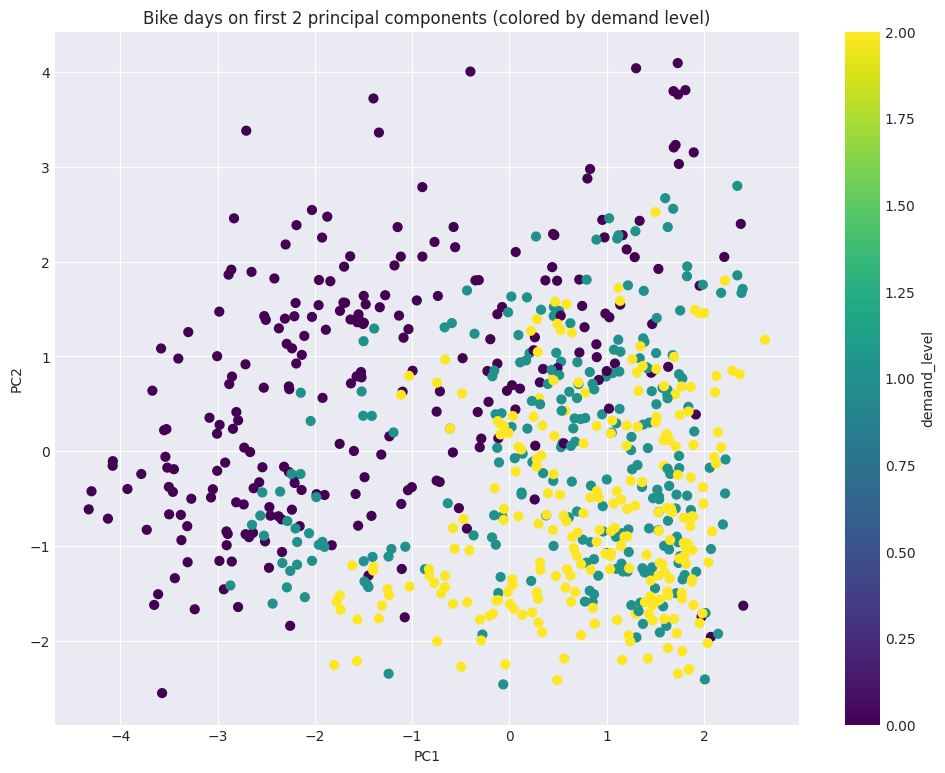

In [27]:
plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=40, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Bike days on first 2 principal components (colored by demand level)")
plt.colorbar(scatter, label="demand_level")

k-means clustering used for:

Given a number of clusters k, it assigns each point to the nearest centroid

It iteratively updates centroids to minimize the within-cluster sum of squared distances

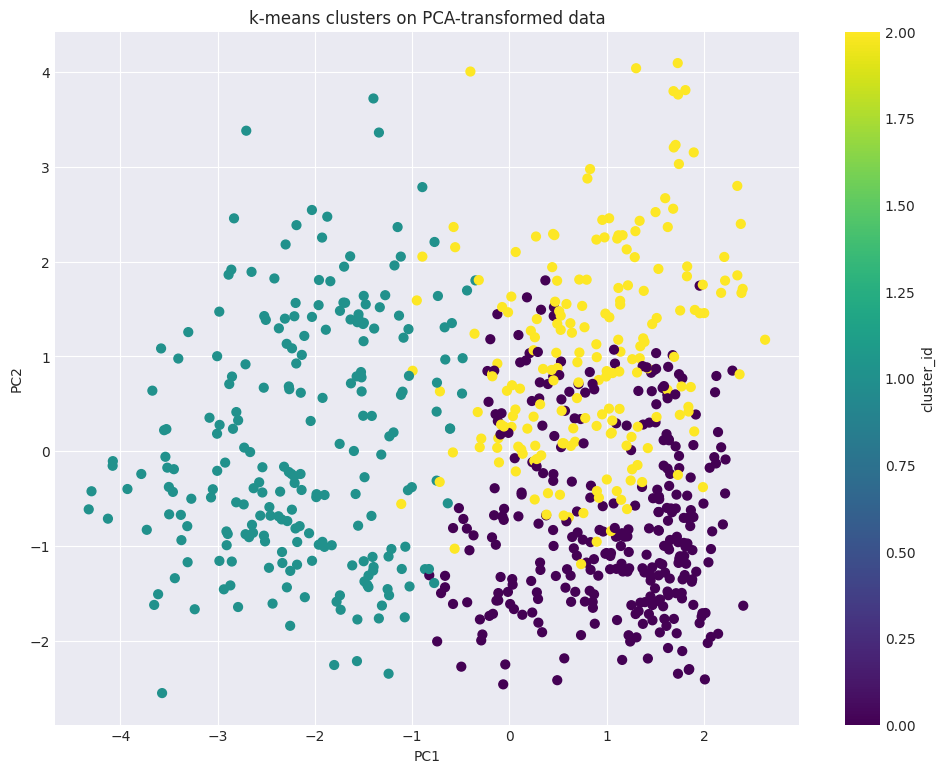

In [28]:
kmeans = KMeans(
    n_clusters=n_classes,
    n_init=100,
    random_state=RANDOM_STATE,
)
kmeans.fit(X_pca)

cluster_labels_kmeans = kmeans.labels_

plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_kmeans, s=40, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("k-means clusters on PCA-transformed data")
plt.colorbar(scatter, label="cluster_id");

to see how well k-means reflects our demand levels, a cross-tabulation computed (similar to a confusion matrix):

In [29]:
tab_kmeans = pd.crosstab(y, cluster_labels_kmeans, margins=True)
tab_kmeans.index = [f"demand_{lvl}" for lvl in np.unique(y)] + ["all"]
tab_kmeans.columns = [f"cluster_{i}" for i in range(n_classes)] + ["all"]
tab_kmeans

,cluster_0,cluster_1,cluster_2,all
demand_0,16,160,68,244
demand_1,131,46,67,244
demand_2,162,22,59,243
all,309,228,194,731


to each demand level, it is possible to compute a simple separability measure

for example if values closer to 1, than that demand level is mostly captured by a single cluster

if lower values, than that demand level is strongly mixed across clusters

In [30]:
separability = pd.Series(
    tab_kmeans.iloc[:-1, :-1].max(axis=1).values / tab_kmeans.iloc[:-1, -1].values,
    index=tab_kmeans.index[:-1],
    name="max_cluster_share",
)
separability

demand_0    0.655738
demand_1    0.536885
demand_2    0.666667
Name: max_cluster_share, dtype: float64

Elbow method for k-means - useful to choose a good number of clusters k

Text(0.5, 1.0, 'Elbow method for k-means on PCA-transformed bike data')

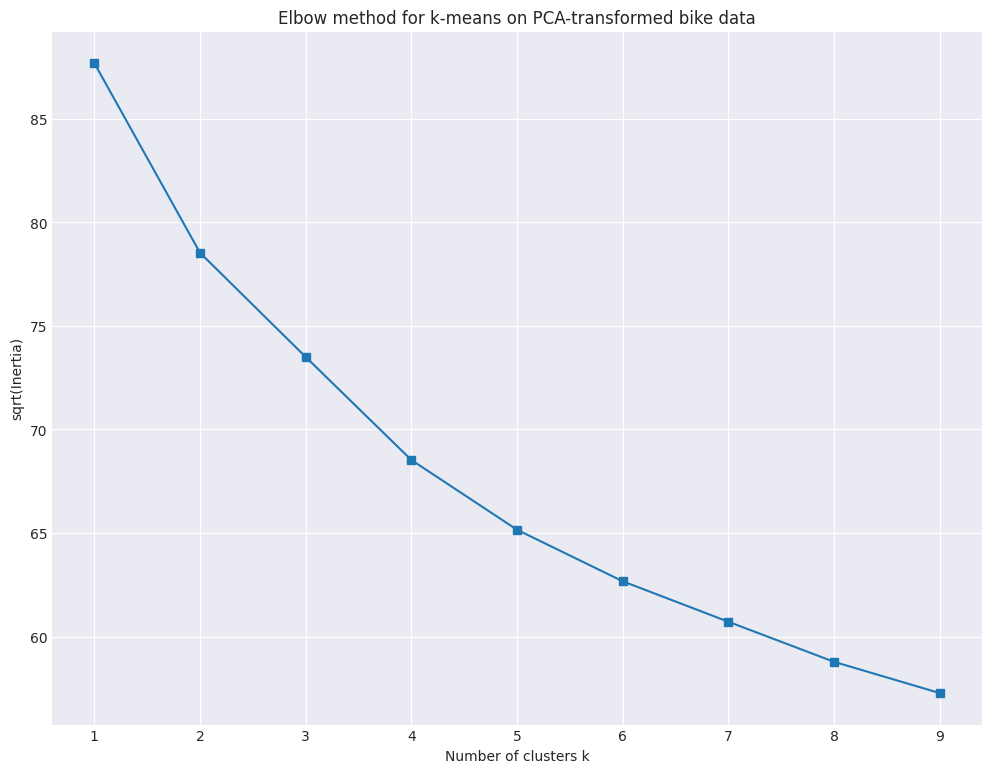

In [32]:
inertia = []
ks = range(1, 10)

for k in ks:
    km = KMeans(n_clusters=k, n_init=100, random_state=RANDOM_STATE).fit(X_pca)
    inertia.append(np.sqrt(km.inertia_))

plt.plot(ks, inertia, marker="s")
plt.xlabel("Number of clusters k")
plt.ylabel("sqrt(Inertia)")
plt.title("Elbow method for k-means on PCA-transformed bike data")

Agglomerative clustering is a bottom-up hierarchical method:

Starts with each point as its own cluster

Iteratively merges the closest clusters according to a linkage criterion

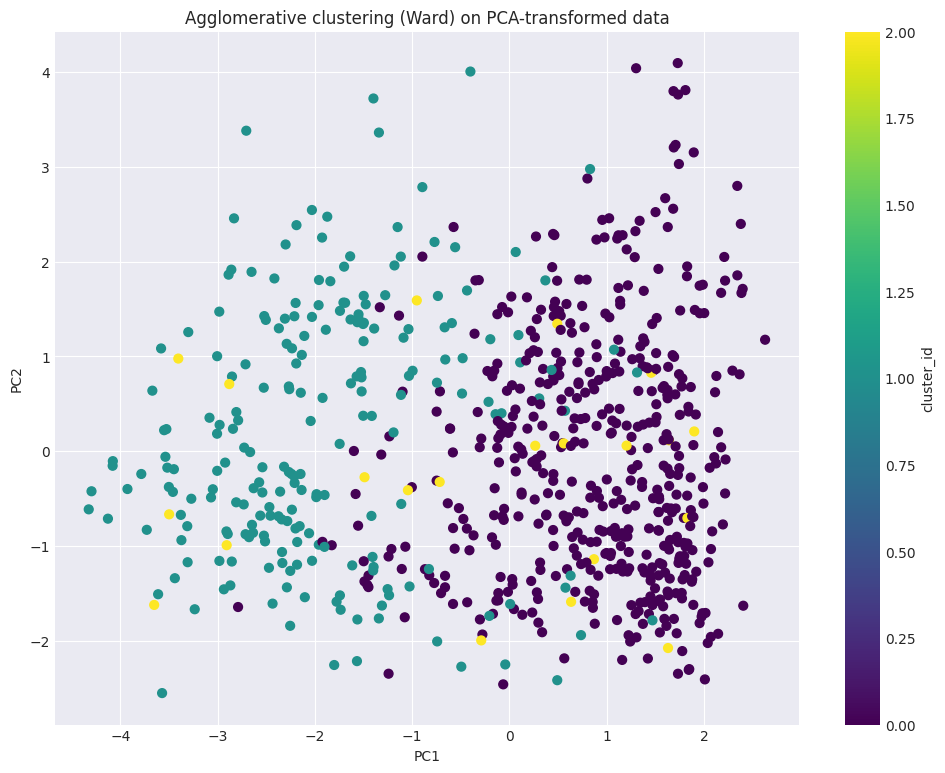

In [ ]:
ag = AgglomerativeClustering(
    n_clusters=n_classes,
    linkage="ward",
)
ag.fit(X_pca)

cluster_labels_ag = ag.labels_

plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_ag, s=40, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative clustering (Ward) on PCA-transformed data")
plt.colorbar(scatter, label="cluster_id")

Spectral clustering is an unsupervised learning method that identifies clusters by analyzing the structure of relationships between data points rather than relying on raw feature space distances.

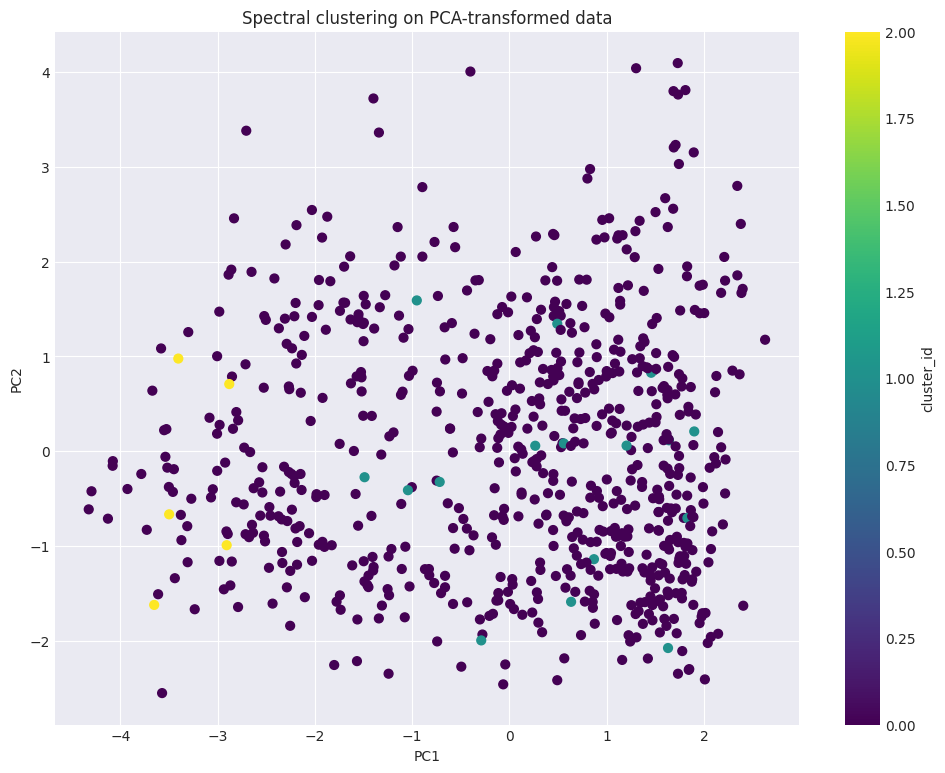

In [ ]:
spec = SpectralClustering(
    n_clusters=n_classes,
    random_state=RANDOM_STATE,
    assign_labels="kmeans",
    n_init=10,
)
cluster_labels_spec = spec.fit_predict(X_pca)

plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_spec, s=40, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Spectral clustering on PCA-transformed data")
plt.colorbar(scatter, label="cluster_id")


Affinity Propagation is a clustering algorithm that:

Treats all points as potential “exemplars”

Uses message-passing between points to decide which points become cluster centers

Does not require pre-specifying the number of clusters

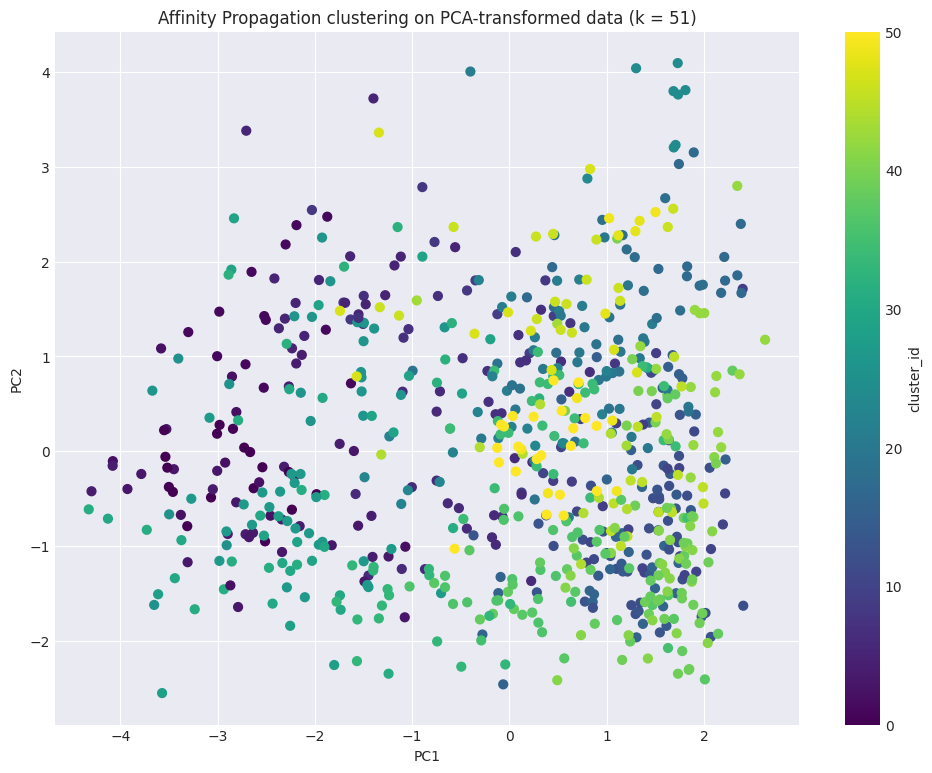

In [ ]:
aff = AffinityPropagation(random_state=RANDOM_STATE)
aff.fit(X_pca)

cluster_labels_aff = aff.labels_
n_clusters_aff = len(np.unique(cluster_labels_aff))
n_clusters_aff
plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_aff, s=40, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Affinity Propagation clustering on PCA-transformed data (k = {n_clusters_aff})")
plt.colorbar(scatter, label="cluster_id")


Metrics

To compare clustering methods, three metrics used:

Adjusted Rand Index (ARI)

Compares cluster assignments with true labels

Corrected for chance

Range: [-1, 1], where 1 means perfect match

Adjusted Mutual Information (AMI)

Measures information shared between clusters and true labels

Corrected for chance

Range: [0, 1], where 1 means perfect agreement

Silhouette score

Uses only distances (no true labels)

Measures how well clusters are separated

Range: [-1, 1], higher is better

In [41]:
def clustering_scores(true_labels, predicted_labels, data):
    ari = metrics.adjusted_rand_score(true_labels, predicted_labels)
    ami = metrics.adjusted_mutual_info_score(true_labels, predicted_labels)
    if len(np.unique(predicted_labels)) > 1:
        sil = metrics.silhouette_score(data, predicted_labels)
    else:
        sil = np.nan
    return ari, ami, sil

results = {}
results["kmeans"] = clustering_scores(y, cluster_labels_kmeans, X_pca)
results["agglomerative"] = clustering_scores(y, cluster_labels_ag, X_pca)
results["affinity"] = clustering_scores(y, cluster_labels_aff, X_pca)
results["spectral"] = clustering_scores(y, cluster_labels_spec, X_pca)

scores_df = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=["ARI", "AMI", "Silhouette"],
)
scores_df

,ARI,AMI,Silhouette
kmeans,0.187601,0.179061,0.192159
agglomerative,0.120963,0.123737,0.207183
affinity,0.048229,0.233246,0.226426
spectral,0.000323,0.011413,0.409402


In [42]:
for name, (ari, ami, sil) in results.items():
    print(f"{name:14s}  ARI = {ari:.4f}   AMI = {ami:.4f}   Silhouette = {sil:.4f}")

kmeans          ARI = 0.1876   AMI = 0.1791   Silhouette = 0.1922
agglomerative   ARI = 0.1210   AMI = 0.1237   Silhouette = 0.2072
affinity        ARI = 0.0482   AMI = 0.2332   Silhouette = 0.2264
spectral        ARI = 0.0003   AMI = 0.0114   Silhouette = 0.4094


Supervised baseline

trained a Linear Support Vector Machine (LinearSVC) to predict demand_level:

Once on original scaled features

Once on PCA-reduced features

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {"C": [0.001, 0.01, 0.1, 1, 10]}

best_svc = GridSearchCV(
    svc,
    svc_params,
    n_jobs=4,
    cv=3,
    verbose=1,
)
best_svc.fit(X_train_scaled, y_train)

best_svc.best_params_, best_svc.best_score_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


({'C': 10}, np.float64(0.8082215342277261))

In [46]:
y_pred = best_svc.predict(X_test_scaled)
print("Test accuracy (no PCA):", metrics.accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy (no PCA): 0.7954545454545454
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        73
           1       0.81      0.58      0.68        74
           2       0.79      0.90      0.84        73

    accuracy                           0.80       220
   macro avg       0.80      0.80      0.79       220
weighted avg       0.80      0.80      0.79       220



LinearSVC with PCA

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_cls = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_train_pca_cls = pca_cls.fit_transform(X_train_scaled)
X_test_pca_cls = pca_cls.transform(X_test_scaled)

svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {"C": [0.001, 0.01, 0.1, 1, 10]}

best_svc_pca = GridSearchCV(
    svc,
    svc_params,
    n_jobs=4,
    cv=3,
    verbose=1,
)
best_svc_pca.fit(X_train_pca_cls, y_train)

best_svc_pca.best_params_, best_svc_pca.best_score_


Fitting 3 folds for each of 5 candidates, totalling 15 fits


({'C': 0.001}, np.float64(0.8082330008026603))

In [48]:
y_pred_pca = best_svc_pca.predict(X_test_pca_cls)
print("Test accuracy (with PCA):", metrics.accuracy_score(y_test, y_pred_pca))
print(classification_report(y_test, y_pred_pca))

Test accuracy (with PCA): 0.8
              precision    recall  f1-score   support

           0       0.78      0.92      0.84        73
           1       0.81      0.58      0.68        74
           2       0.81      0.90      0.86        73

    accuracy                           0.80       220
   macro avg       0.80      0.80      0.79       220
weighted avg       0.80      0.80      0.79       220

